In [7]:
import pandas as pd
import matplotlib as mat
import numpy as np


In [8]:
df = pd.read_csv("Estadistica.csv")

In [9]:
df.columns

Index(['Marca temporal', '¿Qué edad tienes?',
       '¿Qué dispositivos usas principalmente?',
       '¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?',
       '  ¿Cuántas horas diarias pasas, en promedio, específicamente en Redes Sociales? (Instagram, TikTok, Twitter/X, etc.)  ',
       '  ¿Cuál es tu promedio académico actual o estimado en este ciclo lectivo? (Nota del 1 al 10)  ',
       '¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil durante los fines de semana?',
       '¿Cuál es la principal actividad que realiza en su dispositivo móvil?',
       'Indique en qué rango de tiempo usted suele revisar su dispositivo con mayor frecuencia. [Lunes a Viernes]',
       'Indique en qué rango de tiempo usted suele revisar su dispositivo con mayor frecuencia. [Sábados y Domingos]',
       'Evalúe su nivel de dependencia del dispositivo móvil (1 siendo muy baja y 10 siendo muy alta).',
       '¿Considera que su uso de pa

Aqui elegimos las columnas que necesitamos para poder utilizar las siguientes variables que se piden 

In [10]:
columnas_de_interes = ['¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?','¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil durante los fines de semana?','  ¿Cuál es tu promedio académico actual o estimado en este ciclo lectivo? (Nota del 1 al 10)  ']

In [11]:
df_reducido = df[columnas_de_interes]
df_reducido

,"¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?","¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil durante los fines de semana?",¿Cuál es tu promedio académico actual o estimado en este ciclo lectivo? (Nota del 1 al 10)
0,1 a 2 horas,4 a 6 horas,9
1,4 a 6 horas,Más de 6 horas,7
2,4 a 6 horas,Más de 6 horas,8
3,1 a 2 horas,Menos de 1 hora,8
4,4 a 6 horas,4 a 6 horas,8
...,...,...,...
195,Más de 6 horas,Más de 6 horas,9
196,2 a 4 horas,Más de 6 horas,9
197,Más de 6 horas,2 a 4 horas,7
198,Más de 6 horas,1 a 2 horas,9


In [12]:
data = pd.read_csv("datos_limpios.csv")
data['¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?']

0      1.5
1      5.0
2      5.0
3      1.5
4      5.0
      ... 
195    7.0
196    3.0
197    7.0
198    7.0
199    7.0
Name: ¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?, Length: 200, dtype: float64

In [13]:
import pandas as pd

df = pd.read_csv('datos_limpios.csv')
col = '¿Cuál es la principal actividad que realiza en su dispositivo móvil?'

# Mantener solo las filas que mencionan redes sociales
keywords = ['Instagram', 'TikTok', 'Facebook', 'Redes sociales']
mask = df[col].str.contains('|'.join(keywords), case=False, na=False)
df_filtrado = df[mask].copy()

print(f'Filas originales: {len(df)}')
print(f'Filas conservadas (con redes sociales): {len(df_filtrado)}')
print(f'Filas eliminadas: {len(df) - len(df_filtrado)}')

df_filtrado.to_csv('datos_redes_sociales.csv', index=False)

Filas originales: 200
Filas conservadas (con redes sociales): 138
Filas eliminadas: 62


In [14]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('datos_redes_sociales.csv')

# Buscar las columnas automáticamente
col_movil = [c for c in df.columns if 'días laborables' in c.lower()][0]
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

print(f'Columna 1: {col_movil}')
print(f'Columna 2: {col_redes}')

# Extraer solo el número (elimina texto como "horas", "hs", etc.)
df[col_movil] = df[col_movil].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Verificar que quedaron bien
print(df[[col_movil, col_redes]].head(10))

# Normalizar con MinMaxScaler (rango 0 a 1)
scaler = MinMaxScaler()
df[['horas_movil_norm', 'horas_redes_norm']] = scaler.fit_transform(df[[col_movil, col_redes]])

print(df[[col_movil, 'horas_movil_norm', col_redes, 'horas_redes_norm']].head(10))

df.to_csv('datos_normalizados.csv', index=False)

Columna 1: ¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?
Columna 2:   ¿Cuántas horas diarias pasas, en promedio, específicamente en Redes Sociales? (Instagram, TikTok, Twitter/X, etc.)  
   ¿Cuántas horas al día, en promedio, utiliza su dispositivo móvil (celular, tablet) en días laborables?  \
0                                                1.5                                                        
1                                                1.5                                                        
2                                                5.0                                                        
3                                                7.0                                                        
4                                                3.0                                                        
5                                                5.0                                                  

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('datos_normalizados.csv')

# Buscar la columna de horas en redes sociales
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# Extraer solo el número por si quedaron textos
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

datos = df[col_redes].dropna().sort_values()
n = len(datos)

# Tabla de frecuencias
valores = sorted(datos.unique())
tabla = []

fi_acum = 0
hi_acum = 0

for i, valor in enumerate(valores, start=1):
    fi = (datos == valor).sum()          # Frecuencia absoluta
    hi = fi / n                          # Frecuencia relativa
    pi = hi * 100                        # Porcentaje
    fi_acum += fi                        # Frecuencia absoluta acumulada
    hi_acum += hi                        # Frecuencia relativa acumulada
    pi_acum = hi_acum * 100             # Porcentaje acumulado

    tabla.append({
        'i': i,
        'xi (horas)': valor,
        'fi (frec. abs.)': fi,
        'Fi (frec. abs. acum.)': fi_acum,
        'hi (frec. rel.)': round(hi, 4),
        'Hi (frec. rel. acum.)': round(hi_acum, 4),
        'pi (%)': round(pi, 2),
        'Pi (% acum.)': round(pi_acum, 2)
    })

tabla_df = pd.DataFrame(tabla)

# Fila de totales
totales = {
    'i': 'Total',
    'xi (horas)': '-',
    'fi (frec. abs.)': n,
    'Fi (frec. abs. acum.)': '-',
    'hi (frec. rel.)': 1.0,
    'Hi (frec. rel. acum.)': '-',
    'pi (%)': 100.0,
    'Pi (% acum.)': '-'
}
tabla_df = pd.concat([tabla_df, pd.DataFrame([totales])], ignore_index=True)

print(tabla_df.to_string(index=False))

# Exportar a CSV
tabla_df.to_csv('tabla_frecuencias.csv', index=False)
print('\nTabla exportada como tabla_frecuencias.csv')

    i xi (horas)  fi (frec. abs.) Fi (frec. abs. acum.)  hi (frec. rel.) Hi (frec. rel. acum.)  pi (%) Pi (% acum.)
    1        1.0               16                    16           0.1416                0.1416   14.16        14.16
    2        2.0               23                    39           0.2035                0.3451   20.35        34.51
    3        2.3                1                    40           0.0088                 0.354    0.88         35.4
    4        3.0               16                    56           0.1416                0.4956   14.16        49.56
    5        4.0               24                    80           0.2124                 0.708   21.24         70.8
    6        5.0                7                    87           0.0619                0.7699    6.19        76.99
    7        6.0               10                    97           0.0885                0.8584    8.85        85.84
    8        7.0                3                   100           0.0265

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv('datos_normalizados.csv')

# Buscar la columna de horas en redes sociales
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# Limpiar columna
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

datos = df[col_redes].dropna().sort_values()
n = len(datos)

# Reconstruir tabla de frecuencias
valores = sorted(datos.unique())
tabla = []
fi_acum = 0
hi_acum = 0

for i, valor in enumerate(valores, start=1):
    fi = (datos == valor).sum()
    hi = fi / n
    pi = hi * 100
    fi_acum += fi
    hi_acum += hi
    pi_acum = hi_acum * 100
    tabla.append({
        'i': i,
        'xi': valor,
        'fi': fi,
        'Fi': fi_acum,
        'hi': round(hi, 4),
        'Hi': round(hi_acum, 4),
        'pi': round(pi, 2),
        'Pi': round(pi_acum, 2)
    })

tabla_df = pd.DataFrame(tabla)

# Función para obtener valor de la tabla por índice
def obtener(col, indice):
    fila = tabla_df[tabla_df['i'] == indice]
    if fila.empty:
        return None
    return fila[col].values[0]

# ---- INTERPRETACIONES ----
print("=" * 60)
print("        INTERPRETACIÓN DE FRECUENCIAS")
print("=" * 60)

# Frecuencias absolutas simples (fi)
for idx in [2, 5, 8]:
    val = obtener('fi', idx)
    xi  = obtener('xi', idx)
    if val is not None:
        print(f"\nf{idx} = {val}")
        print(f"  → {int(val)} estudiantes utilizan exactamente {xi} horas diarias en redes sociales.")

print()

# Frecuencias absolutas acumuladas (Fi)
for idx in [4, 7, 10]:
    val = obtener('Fi', idx)
    xi  = obtener('xi', idx)
    if val is not None:
        print(f"F{idx} = {val}")
        print(f"  → {int(val)} estudiantes utilizan hasta {xi} horas diarias en redes sociales.")

print()

# Frecuencias relativas simples (pi = porcentaje)
for idx in [3, 6, 9]:
    val = obtener('pi', idx)
    xi  = obtener('xi', idx)
    if val is not None:
        print(f"p{idx} = {val}%")
        print(f"  → El {val}% de los estudiantes utiliza exactamente {xi} horas diarias en redes sociales.")

print()

# Frecuencias relativas acumuladas (Pi = porcentaje acumulado)
for idx in [8, 12]:
    val = obtener('Pi', idx)
    xi  = obtener('xi', idx)
    if val is not None:
        print(f"P{idx} = {val}%")
        print(f"  → El {val}% de los estudiantes utiliza hasta {xi} horas diarias en redes sociales.")

        INTERPRETACIÓN DE FRECUENCIAS

f2 = 23
  → 23 estudiantes utilizan exactamente 2.0 horas diarias en redes sociales.

f5 = 24
  → 24 estudiantes utilizan exactamente 4.0 horas diarias en redes sociales.

f8 = 3
  → 3 estudiantes utilizan exactamente 7.0 horas diarias en redes sociales.

F4 = 56
  → 56 estudiantes utilizan hasta 3.0 horas diarias en redes sociales.
F7 = 97
  → 97 estudiantes utilizan hasta 6.0 horas diarias en redes sociales.
F10 = 107
  → 107 estudiantes utilizan hasta 10.0 horas diarias en redes sociales.

p3 = 0.88%
  → El 0.88% de los estudiantes utiliza exactamente 2.3 horas diarias en redes sociales.
p6 = 6.19%
  → El 6.19% de los estudiantes utiliza exactamente 5.0 horas diarias en redes sociales.
p9 = 4.42%
  → El 4.42% de los estudiantes utiliza exactamente 8.0 horas diarias en redes sociales.

P8 = 88.5%
  → El 88.5% de los estudiantes utiliza hasta 7.0 horas diarias en redes sociales.
P12 = 99.12%
  → El 99.12% de los estudiantes utiliza hasta 20.0 hor

In [17]:
import pandas as pd

df = pd.read_csv('datos_normalizados.csv')

# Buscar la columna de horas en redes sociales
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# Limpiar columna
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

datos = df[col_redes].dropna()
n = len(datos)

print("=" * 60)
print("         DETERMINACIÓN DE CANTIDADES Y PORCENTAJES")
print("=" * 60)

# Cantidad entre 3 y 8 horas
cant_3_8 = ((datos >= 3) & (datos <= 8)).sum()
print(f"\nCantidad de estudiantes que utilizan entre 3 y 8 horas diarias:")
print(f"  → {cant_3_8} estudiantes")

# Porcentaje más de 6 horas
porc_mas6 = ((datos > 6).sum() / n) * 100
print(f"\nPorcentaje de estudiantes que utilizan más de 6 horas diarias:")
print(f"  → {round(porc_mas6, 2)}%")

# Cantidad menos de 2 horas
cant_menos2 = (datos < 2).sum()
print(f"\nCantidad de estudiantes que utilizan menos de 2 horas diarias:")
print(f"  → {cant_menos2} estudiantes")

# Porcentaje entre 5 y 10 horas
porc_5_10 = (((datos >= 5) & (datos <= 10)).sum() / n) * 100
print(f"\nPorcentaje de estudiantes que utilizan entre 5 y 10 horas diarias:")
print(f"  → {round(porc_5_10, 2)}%")

# Cantidad más de 8 horas
cant_mas8 = (datos > 8).sum()
print(f"\nCantidad de estudiantes que utilizan más de 8 horas diarias:")
print(f"  → {cant_mas8} estudiantes")

# Porcentaje menos de 4 horas
porc_menos4 = ((datos < 4).sum() / n) * 100
print(f"\nPorcentaje de estudiantes que utilizan menos de 4 horas diarias:")
print(f"  → {round(porc_menos4, 2)}%")

# Cantidad entre 1 y 6 horas
cant_1_6 = ((datos >= 1) & (datos <= 6)).sum()
print(f"\nCantidad de estudiantes que utilizan entre 1 y 6 horas diarias:")
print(f"  → {cant_1_6} estudiantes")

# Porcentaje más de 9 horas
porc_mas9 = ((datos > 9).sum() / n) * 100
print(f"\nPorcentaje de estudiantes que utilizan más de 9 horas diarias:")
print(f"  → {round(porc_mas9, 2)}%")

         DETERMINACIÓN DE CANTIDADES Y PORCENTAJES

Cantidad de estudiantes que utilizan entre 3 y 8 horas diarias:
  → 65 estudiantes

Porcentaje de estudiantes que utilizan más de 6 horas diarias:
  → 14.16%

Cantidad de estudiantes que utilizan menos de 2 horas diarias:
  → 16 estudiantes

Porcentaje de estudiantes que utilizan entre 5 y 10 horas diarias:
  → 23.89%

Cantidad de estudiantes que utilizan más de 8 horas diarias:
  → 8 estudiantes

Porcentaje de estudiantes que utilizan menos de 4 horas diarias:
  → 49.56%

Cantidad de estudiantes que utilizan entre 1 y 6 horas diarias:
  → 97 estudiantes

Porcentaje de estudiantes que utilizan más de 9 horas diarias:
  → 7.08%


In [18]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('datos_normalizados.csv')

# Buscar la columna de horas en redes sociales
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# Limpiar columna
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

datos = df[col_redes].dropna()

print("=" * 60)
print("       MEDIDAS DE TENDENCIA CENTRAL Y FORMA")
print("=" * 60)

# Media aritmética
media = datos.mean()
print(f"\nMedia aritmética: {round(media, 2)}")
print(f"  → En promedio, los estudiantes utilizan {round(media, 2)} horas diarias en redes sociales.")

# Moda
moda = datos.mode()
print(f"\nModa: {moda.values}")
print(f"  → El valor que más se repite es {moda.values[0]} horas diarias, es decir, es la cantidad más frecuente entre los estudiantes.")

# Mediana
mediana = datos.median()
print(f"\nMediana: {round(mediana, 2)}")
print(f"  → El 50% de los estudiantes utiliza hasta {round(mediana, 2)} horas diarias en redes sociales, y el otro 50% utiliza más.")

# Coeficiente de asimetría
asimetria = datos.skew()
print(f"\nCoeficiente de asimetría: {round(asimetria, 4)}")
if asimetria > 0:
    print(f"  → La distribución es asimétrica positiva (cola hacia la derecha).")
    print(f"     La mayoría de los estudiantes usa pocas horas, pero hay casos con un uso muy elevado.")
elif asimetria < 0:
    print(f"  → La distribución es asimétrica negativa (cola hacia la izquierda).")
    print(f"     La mayoría de los estudiantes usa muchas horas, con pocos casos de uso muy bajo.")
else:
    print(f"  → La distribución es perfectamente simétrica.")

# Curtosis
curtosis = datos.kurt()
print(f"\nCurtosis: {round(curtosis, 4)}")
if curtosis > 0:
    print(f"  → Distribución leptocúrtica: más apuntada que la normal.")
    print(f"     Los datos se concentran fuertemente alrededor de la media.")
elif curtosis < 0:
    print(f"  → Distribución platicúrtica: más aplanada que la normal.")
    print(f"     Los datos están más dispersos y repartidos.")
else:
    print(f"  → Distribución mesocúrtica: igual apuntamiento que la normal.")

       MEDIDAS DE TENDENCIA CENTRAL Y FORMA

Media aritmética: 4.34
  → En promedio, los estudiantes utilizan 4.34 horas diarias en redes sociales.

Moda: [4.]
  → El valor que más se repite es 4.0 horas diarias, es decir, es la cantidad más frecuente entre los estudiantes.

Mediana: 4.0
  → El 50% de los estudiantes utiliza hasta 4.0 horas diarias en redes sociales, y el otro 50% utiliza más.

Coeficiente de asimetría: 2.9082
  → La distribución es asimétrica positiva (cola hacia la derecha).
     La mayoría de los estudiantes usa pocas horas, pero hay casos con un uso muy elevado.

Curtosis: 10.2718
  → Distribución leptocúrtica: más apuntada que la normal.
     Los datos se concentran fuertemente alrededor de la media.


In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('datos_normalizados.csv')

# Buscar la columna de horas en redes sociales
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# Limpiar columna
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

datos = df[col_redes].dropna()

print("=" * 60)
print("          MEDIDAS DE DISPERSIÓN")
print("=" * 60)

# Varianza
varianza = datos.var()
print(f"\nVarianza: {round(varianza, 4)}")
print(f"  → Los datos se desvían en promedio {round(varianza, 4)} unidades cuadradas")
print(f"     respecto a la media. Cuanto mayor es este valor,")
print(f"     más dispersos están los datos.")

# Desvío estándar
desvio = datos.std()
print(f"\nDesvío estándar: {round(desvio, 4)}")
print(f"  → En promedio, los estudiantes se alejan {round(desvio, 2)} horas")
print(f"     de la media en su uso diario de redes sociales.")

# Coeficiente de variación
media = datos.mean()
cv = (desvio / media) * 100
print(f"\nCoeficiente de variación: {round(cv, 2)}%")
if cv < 15:
    print(f"  → Variación baja: los datos son muy homogéneos.")
    print(f"     Los estudiantes tienen un uso similar de redes sociales.")
elif cv <= 30:
    print(f"  → Variación moderada: los datos presentan dispersión aceptable.")
    print(f"     Existe cierta diferencia en el uso entre los estudiantes.")
else:
    print(f"  → Variación alta: los datos son muy heterogéneos.")
    print(f"     El uso de redes sociales varía considerablemente entre estudiantes.")

          MEDIDAS DE DISPERSIÓN

Varianza: 15.4813
  → Los datos se desvían en promedio 15.4813 unidades cuadradas
     respecto a la media. Cuanto mayor es este valor,
     más dispersos están los datos.

Desvío estándar: 3.9346
  → En promedio, los estudiantes se alejan 3.93 horas
     de la media en su uso diario de redes sociales.

Coeficiente de variación: 90.68%
  → Variación alta: los datos son muy heterogéneos.
     El uso de redes sociales varía considerablemente entre estudiantes.


In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv('datos_normalizados.csv')

# Buscar la columna de horas en redes sociales
col_redes = [c for c in df.columns if 'redes sociales' in c.lower() and 'horas diarias' in c.lower()][0]

# Limpiar columna
df[col_redes] = df[col_redes].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

datos = df[col_redes].dropna()

print("=" * 60)
print("        CUARTILES, DECILES Y PERCENTILES")
print("=" * 60)

# ---- CUARTILES ----
print("\n--- CUARTILES ---")

Q1 = np.percentile(datos, 25)
Q3 = np.percentile(datos, 75)

print(f"\nQ1 = {round(Q1, 2)}")
print(f"  → El 25% de los estudiantes utiliza hasta {round(Q1, 2)} horas")
print(f"     diarias en redes sociales.")

print(f"\nQ3 = {round(Q3, 2)}")
print(f"  → El 75% de los estudiantes utiliza hasta {round(Q3, 2)} horas")
print(f"     diarias en redes sociales. Solo el 25% supera este valor.")

# ---- DECILES ----
print("\n--- DECILES ---")

D3 = np.percentile(datos, 30)
D4 = np.percentile(datos, 40)
D9 = np.percentile(datos, 90)

print(f"\nD3 = {round(D3, 2)}")
print(f"  → El 30% de los estudiantes utiliza hasta {round(D3, 2)} horas")
print(f"     diarias en redes sociales.")

print(f"\nD4 = {round(D4, 2)}")
print(f"  → El 40% de los estudiantes utiliza hasta {round(D4, 2)} horas")
print(f"     diarias en redes sociales.")

print(f"\nD9 = {round(D9, 2)}")
print(f"  → El 90% de los estudiantes utiliza hasta {round(D9, 2)} horas")
print(f"     diarias en redes sociales. Solo el 10% supera este valor.")

# ---- PERCENTILES ----
print("\n--- PERCENTILES ---")

P23 = np.percentile(datos, 23)
P75 = np.percentile(datos, 75)
P97 = np.percentile(datos, 97)

print(f"\nP23 = {round(P23, 2)}")
print(f"  → El 23% de los estudiantes utiliza hasta {round(P23, 2)} horas")
print(f"     diarias en redes sociales.")

print(f"\nP75 = {round(P75, 2)}")
print(f"  → El 75% de los estudiantes utiliza hasta {round(P75, 2)} horas")
print(f"     diarias en redes sociales.")

print(f"\nP97 = {round(P97, 2)}")
print(f"  → El 97% de los estudiantes utiliza hasta {round(P97, 2)} horas")
print(f"     diarias en redes sociales. Solo el 3% supera este valor,")
print(f"     representando los casos de uso más extremo.")

        CUARTILES, DECILES Y PERCENTILES

--- CUARTILES ---

Q1 = 2.0
  → El 25% de los estudiantes utiliza hasta 2.0 horas
     diarias en redes sociales.

Q3 = 5.0
  → El 75% de los estudiantes utiliza hasta 5.0 horas
     diarias en redes sociales. Solo el 25% supera este valor.

--- DECILES ---

D3 = 2.0
  → El 30% de los estudiantes utiliza hasta 2.0 horas
     diarias en redes sociales.

D4 = 3.0
  → El 40% de los estudiantes utiliza hasta 3.0 horas
     diarias en redes sociales.

D9 = 8.0
  → El 90% de los estudiantes utiliza hasta 8.0 horas
     diarias en redes sociales. Solo el 10% supera este valor.

--- PERCENTILES ---

P23 = 2.0
  → El 23% de los estudiantes utiliza hasta 2.0 horas
     diarias en redes sociales.

P75 = 5.0
  → El 75% de los estudiantes utiliza hasta 5.0 horas
     diarias en redes sociales.

P97 = 16.76
  → El 97% de los estudiantes utiliza hasta 16.76 horas
     diarias en redes sociales. Solo el 3% supera este valor,
     representando los casos de uso

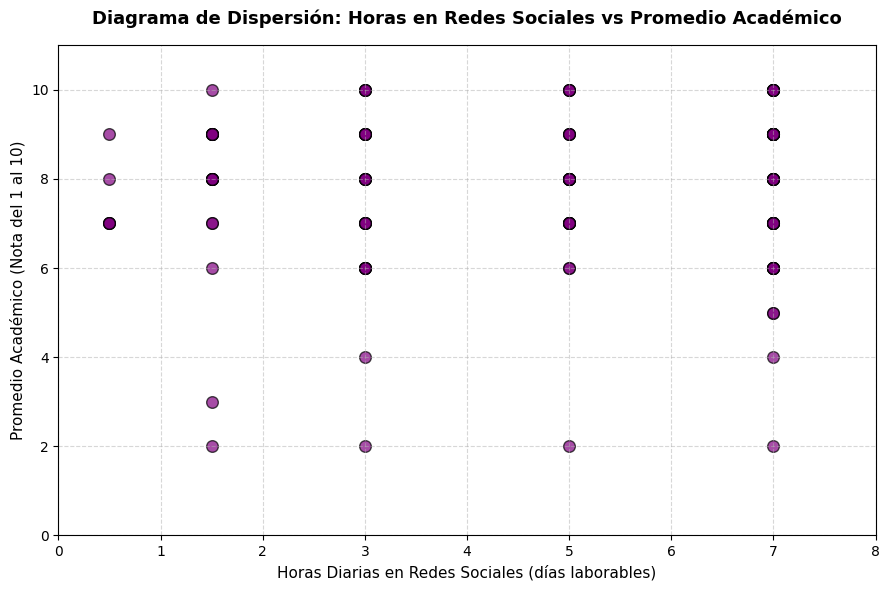

Gráfico guardado como 'a_diagrama_dispersion.png'


In [29]:
# ============================================================
# a) DIAGRAMA DE DISPERSIÓN
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_nuevo = pd.read_csv("Estadistica.csv")

col_actividad = [c for c in df_nuevo.columns if 'actividad' in c.lower()][0]
col_horas     = [c for c in df_nuevo.columns if 'horas al día' in c.lower() and 'laborables' in c.lower()][0]
col_promedio  = [c for c in df_nuevo.columns if 'promedio académico' in c.lower() or 'nota del 1 al 10' in c.lower()][0]

df_filtrado = df_nuevo[df_nuevo[col_actividad].str.contains("Redes sociales", na=False)].copy()

mapeo_intervalos = {
    "Menos de 1 hora": 0.5,
    "1 a 2 horas": 1.5,
    "2 a 4 horas": 3.0,
    "4 a 6 horas": 5.0,
    "Más de 6 horas": 7.0
}

X = df_filtrado[col_horas].map(mapeo_intervalos)
Y = pd.to_numeric(df_filtrado[col_promedio], errors='coerce')

df_reg = pd.DataFrame({'Horas': X, 'Notas': Y}).dropna()

plt.figure(figsize=(9, 6))
plt.scatter(df_reg['Horas'], df_reg['Notas'], color='purple', alpha=0.7, edgecolors='black', s=70)

plt.title('Diagrama de Dispersión: Horas en Redes Sociales vs Promedio Académico', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Horas Diarias en Redes Sociales (días laborables)', fontsize=11)
plt.ylabel('Promedio Académico (Nota del 1 al 10)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 8)
plt.ylim(0, 11)
plt.tight_layout()
plt.savefig('a_diagrama_dispersion.png', dpi=150)
plt.show()
print("Gráfico guardado como 'a_diagrama_dispersion.png'")

In [23]:
# ============================================================
# b) TIPO DE CORRELACIÓN OBSERVADA
# ============================================================
from scipy import stats

pendiente, ordenada, r, p_value, std_err = stats.linregress(df_reg['Horas'], df_reg['Notas'])

print("=== b) TIPO DE CORRELACIÓN OBSERVADA ===")
print(f"\nr de Pearson = {round(r, 4)}")

# Dirección
if r > 0:
    direccion = "positiva"
    desc = "A mayor cantidad de horas en redes sociales, mayor promedio académico."
else:
    direccion = "negativa"
    desc = "A mayor cantidad de horas en redes sociales, menor promedio académico."

# Intensidad
if abs(r) >= 0.9:
    intensidad = "muy fuerte"
elif abs(r) >= 0.7:
    intensidad = "fuerte"
elif abs(r) >= 0.5:
    intensidad = "moderada"
elif abs(r) >= 0.3:
    intensidad = "débil"
else:
    intensidad = "muy débil o prácticamente nula"

print(f"  → Correlación lineal {direccion} y {intensidad}.")
print(f"     {desc}")

=== b) TIPO DE CORRELACIÓN OBSERVADA ===

r de Pearson = 0.041
  → Correlación lineal positiva y muy débil o prácticamente nula.
     A mayor cantidad de horas en redes sociales, mayor promedio académico.


=== c) RECTA DE REGRESIÓN ===

Y = 7.5542 + (0.0317) * X

  Donde:
    X = horas diarias en redes sociales
    Y = promedio académico estimado
    a (ordenada al origen) = 7.5542
    b (pendiente)          = 0.0317


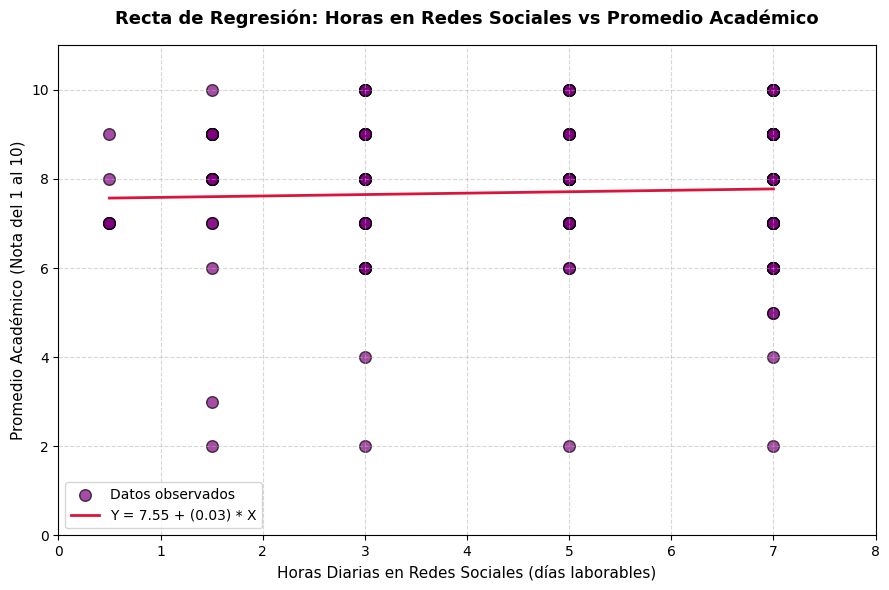

Gráfico guardado como 'c_recta_regresion.png'


In [28]:
# ============================================================
# c) RECTA DE REGRESIÓN
#    Fórmula: Y = a + b * X
#    b = (n*ΣXY - ΣX*ΣY) / (n*ΣX² - (ΣX)²)
#    a = Ȳ - b * X̄
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

print("=== c) RECTA DE REGRESIÓN ===")
print(f"\nY = {round(ordenada, 4)} + ({round(pendiente, 4)}) * X")
print(f"\n  Donde:")
print(f"    X = horas diarias en redes sociales")
print(f"    Y = promedio académico estimado")
print(f"    a (ordenada al origen) = {round(ordenada, 4)}")
print(f"    b (pendiente)          = {round(pendiente, 4)}")

X_linea = np.linspace(df_reg['Horas'].min(), df_reg['Horas'].max(), 100)
Y_linea = ordenada + pendiente * X_linea

plt.figure(figsize=(9, 6))
plt.scatter(df_reg['Horas'], df_reg['Notas'], color='purple', alpha=0.7, edgecolors='black', s=70, label='Datos observados')
plt.plot(X_linea, Y_linea, color='crimson', linewidth=2, label=f'Y = {round(ordenada,2)} + ({round(pendiente,2)}) * X')

plt.title('Recta de Regresión: Horas en Redes Sociales vs Promedio Académico', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Horas Diarias en Redes Sociales (días laborables)', fontsize=11)
plt.ylabel('Promedio Académico (Nota del 1 al 10)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 8)
plt.ylim(0, 11)
plt.tight_layout()
plt.savefig('c_recta_regresion.png', dpi=150)
plt.show()
print("Gráfico guardado como 'c_recta_regresion.png'")

In [25]:
# ============================================================
# d) INTERPRETACIÓN DE LA PENDIENTE
#    b indica cuánto varía Y por cada unidad que aumenta X
# ============================================================

print("=== d) INTERPRETACIÓN DE LA PENDIENTE ===")
print(f"\nb = {round(pendiente, 4)}")

if pendiente < 0:
    print(f"\n  → Por cada hora adicional que un estudiante dedica a las")
    print(f"     redes sociales, su promedio académico disminuye")
    print(f"     {round(abs(pendiente), 4)} puntos en promedio.")
    print(f"\n     Esto sugiere que el mayor uso de redes sociales tiene")
    print(f"     un impacto negativo sobre el rendimiento académico.")
else:
    print(f"\n  → Por cada hora adicional que un estudiante dedica a las")
    print(f"     redes sociales, su promedio académico aumenta")
    print(f"     {round(pendiente, 4)} puntos en promedio.")

=== d) INTERPRETACIÓN DE LA PENDIENTE ===

b = 0.0317

  → Por cada hora adicional que un estudiante dedica a las
     redes sociales, su promedio académico aumenta
     0.0317 puntos en promedio.


In [26]:
# ============================================================
# e) COEFICIENTE DE CORRELACIÓN LINEAL DE PEARSON
#    r = (n*ΣXY - ΣX*ΣY) / √[(n*ΣX² - (ΣX)²) * (n*ΣY² - (ΣY)²)]
# ============================================================

print("=== e) COEFICIENTE DE CORRELACIÓN LINEAL ===")
print(f"\nr = {round(r, 4)}")
print(f"\n  → Existe una correlación lineal {direccion} y {intensidad}")
print(f"     entre las horas diarias en redes sociales y el promedio académico.")
print(f"\n  Escala de referencia:")
print(f"     |r| >= 0.9  → muy fuerte")
print(f"     |r| >= 0.7  → fuerte")
print(f"     |r| >= 0.5  → moderada")
print(f"     |r| >= 0.3  → débil")
print(f"     |r|  < 0.3  → muy débil o nula")

=== e) COEFICIENTE DE CORRELACIÓN LINEAL ===

r = 0.041

  → Existe una correlación lineal positiva y muy débil o prácticamente nula
     entre las horas diarias en redes sociales y el promedio académico.

  Escala de referencia:
     |r| >= 0.9  → muy fuerte
     |r| >= 0.7  → fuerte
     |r| >= 0.5  → moderada
     |r| >= 0.3  → débil
     |r|  < 0.3  → muy débil o nula


In [27]:
# ============================================================
# f) COEFICIENTE DE DETERMINACIÓN
#    R² = r²
#    Indica qué porcentaje de la variación de Y
#    es explicada por X
# ============================================================

r2 = r ** 2

print("=== f) COEFICIENTE DE DETERMINACIÓN ===")
print(f"\nR² = r² = ({round(r, 4)})² = {round(r2, 4)}")
print(f"\n  → El {round(r2 * 100, 2)}% de la variación en el promedio académico")
print(f"     es explicada por las horas diarias dedicadas a redes sociales.")
print(f"\n  → El {round((1 - r2) * 100, 2)}% restante se debe a otros factores")
print(f"     no contemplados en este modelo (hábitos de estudio,")
print(f"     asistencia, motivación, etc.)")

=== f) COEFICIENTE DE DETERMINACIÓN ===

R² = r² = (0.041)² = 0.0017

  → El 0.17% de la variación en el promedio académico
     es explicada por las horas diarias dedicadas a redes sociales.

  → El 99.83% restante se debe a otros factores
     no contemplados en este modelo (hábitos de estudio,
     asistencia, motivación, etc.)
